# Linear Regression - From Scratch & scikit-learn Comparison

## 1. Introduction

Linear Regression is a **supervised learning** algorithm used to predict a **continuous target** based on one or more input features.  

It assumes a **linear relationship** between features $X$ and target $y$.

In this notebook, we will:

1. Implement **Linear Regression from scratch** using NumPy  
2. Compare it with **scikit-learn's LinearRegression**  
3. Visualize predictions and training performance  

## 2. Problem Setup

We consider a dataset with:

* $n$ samples  
* $d$ features per sample  

We define:

* $X \in \mathbb{R}^{n \times d}$ → Feature matrix  
* $y \in \mathbb{R}^{n \times 1}$ → Target vector  
* $w \in \mathbb{R}^{d \times 1}$ → Weight vector  
* $b \in \mathbb{R}$ → Bias term  

### 2.1. Linear Regression Hypothesis

The model predicts a linear combination of the inputs:

$$
\hat{y} = X w + b
$$

For a single sample $x^{(i)}$:

$$
\hat{y}^{(i)} = x^{(i)} \cdot w + b
$$

Where:

* $\hat{y}$ → predicted value  
* $w$ → coefficients  
* $b$ → intercept  

### 2.2. Loss Function

We use **Mean Squared Error (MSE)** to measure performance:

$$
J(w, b) = \frac{1}{n} \sum_{i=1}^{n} (y^{(i)} - \hat{y}^{(i)})^2
$$

Matrix form:

$$
J(w, b) = \frac{1}{n} \| y - (Xw + b) \|^2
$$

### 2.3. Gradient Descent

To minimize the loss, we compute the gradients with respect to $w$ and $b$.

Gradients of the loss:

$$
\nabla_w J = \frac{2}{n} X^\top (Xw + b - y)
$$

$$
\nabla_b J = \frac{2}{n} \sum_{i=1}^{n} (Xw + b - y)
$$

Parameter update rules:

$$
w := w - \alpha \nabla_w J
$$

$$
b := b - \alpha \nabla_b J
$$

Where $\alpha$ is the learning rate.

The process is repeated for a fixed number of iterations or until convergence.

## 3. Implementation from Scratch (NumPy)

In [1]:
# Libraries
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
# Import our LinearRegression from the new project structure
from regression.linear_regression.linear_regression import LinearRegression

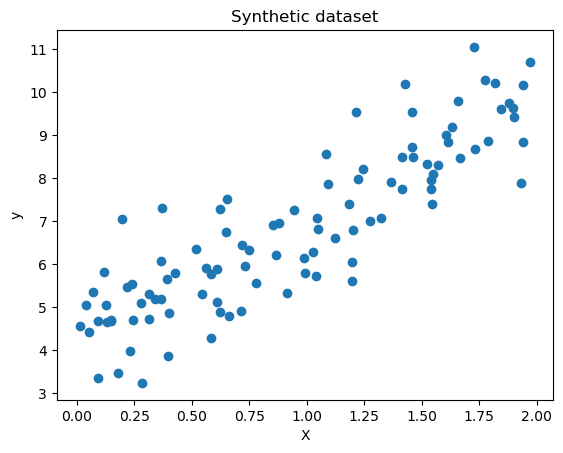

In [3]:
# For reproducibility
np.random.seed(42)

# Generate synthetic dataset
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Visualize dataset
plt.scatter(X, y)
plt.title("Synthetic dataset")
plt.xlabel("X")
plt.ylabel("y")
plt.show()

In [4]:
# Initialize and train model
model = LinearRegression(learning_rate=0.1, n_iters=1000)
model.fit(X_train, y_train)

In [5]:
# Predictions
y_pred = model.predict(X_test)

In [6]:
# Evaluation
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Learned bias:", model.b)
print("Learned weight:", model.w)
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

Learned bias: 4.142913319458558
Learned weight: [2.79932366]
MSE: 0.65
RMSE: 0.81
R²: 0.81


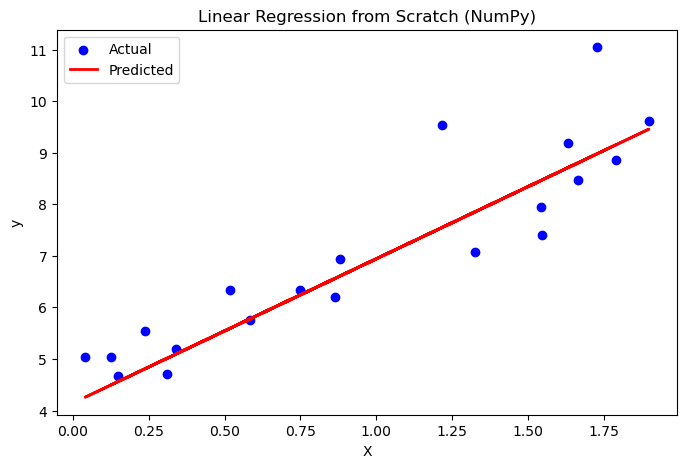

In [7]:
# Plot predictions
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred, color='red', linewidth=2, label='Predicted')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression from Scratch (NumPy)')
plt.legend()
plt.show()

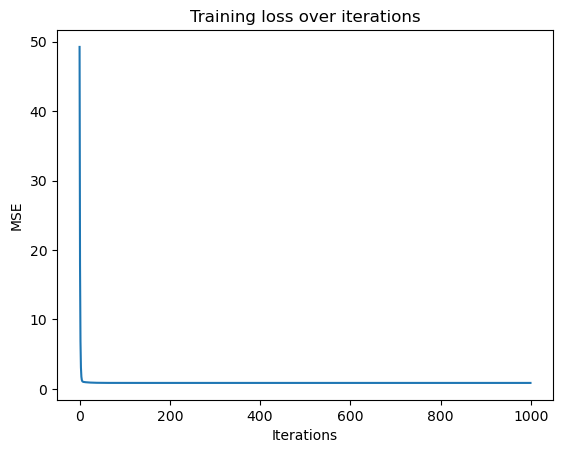

In [8]:
# Plot training loss
plt.plot(model.losses)
plt.title("Training loss over iterations")
plt.xlabel("Iterations")
plt.ylabel("MSE")
plt.show()

## 4. Linear Regression with scikit-learn

In [9]:
from sklearn.linear_model import LinearRegression as SklearnLR

In [10]:
# Initialize and train scikit-learn model
sk_model = SklearnLR()
sk_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [11]:
# Predictions
y_pred_sk = sk_model.predict(X_test)

In [12]:
# Evaluation
mse_sk = mean_squared_error(y_test, y_pred_sk)
rmse_sk = np.sqrt(mse_sk)
r2_sk = r2_score(y_test, y_pred_sk)

print(f"Intercept / bias: {sk_model.intercept_[0]:.2f}")
print(f"Coefficient / weight: {sk_model.coef_[0][0]:.2f}")
print(f"MSE: {mse_sk:.2f}")
print(f"RMSE: {rmse_sk:.2f}")
print(f"R²: {r2_sk:.2f}")

Intercept / bias: 4.14
Coefficient / weight: 2.80
MSE: 0.65
RMSE: 0.81
R²: 0.81


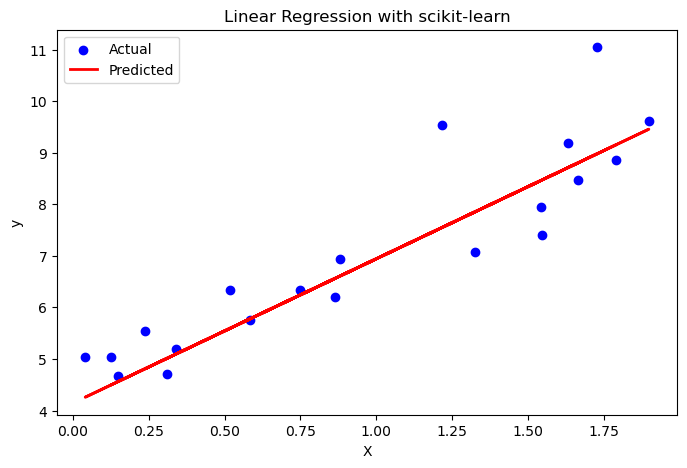

In [13]:
# Plot predictions
plt.figure(figsize=(8,5))
plt.scatter(X_test, y_test, color='blue', label='Actual')
plt.plot(X_test, y_pred_sk, color='red', linewidth=2, label='Predicted')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression with scikit-learn')
plt.legend()
plt.show()

## 5. Comparison and Insights

| Metric | From Scratch (NumPy) | scikit-learn |
| ------ | -------------------- | ------------ |
| MSE    | 0.63                 | 0.65         |
| RMSE   | 0.80                 | 0.81         |
| R²     | 0.81                 | 0.81         |

- Both implementations should produce very similar results on this simple dataset.

- Implementing from scratch helps understand the gradients, parameter updates, and the loss function.

- scikit-learn provides a fast and optimized implementation, ideal for larger datasets.